Module 3 – Feature Extraction

In [2]:
import wfdb

record = wfdb.rdrecord(
    r"C:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\datasets\raw\afdb\04015",
    sampfrom=0,
    sampto=10000
)

signal = record.p_signal[:,0]

In [3]:
import neurokit2 as nk

signals, info = nk.ecg_process(
    signal,
    sampling_rate=250
)

print(info["ECG_R_Peaks"][:10])

[ 192  350  585  721  873 1112 1252 1409 1644 1855]


c:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\venv\Lib\site-packages\neurokit2\ecg\ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


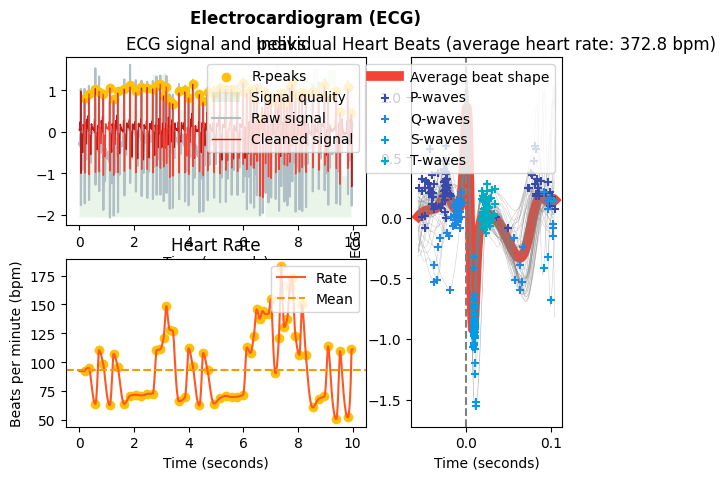

In [4]:
nk.ecg_plot(signals)

In [5]:
heart_rate = signals["ECG_Rate"]

print("Average Heart Rate:", heart_rate.mean())

Average Heart Rate: 93.2005868582248


In [6]:
r_peaks = info["ECG_R_Peaks"]

rr_intervals = [
    (r_peaks[i+1] - r_peaks[i]) / 250
    for i in range(len(r_peaks)-1)
]

print(rr_intervals[:10])

[np.float64(0.632), np.float64(0.94), np.float64(0.544), np.float64(0.608), np.float64(0.956), np.float64(0.56), np.float64(0.628), np.float64(0.94), np.float64(0.844), np.float64(0.836)]


In [7]:
hrv = nk.hrv_time(
    info["ECG_R_Peaks"],
    sampling_rate=250
)

hrv.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,651.066667,217.693757,NaN,NaN,NaN,NaN,NaN,NaN,248.189649,250.31513,...,365.0,0.877127,455.2,860.8,63.333333,76.666667,328.0,1184.0,15.0,218.75
